<a href="https://colab.research.google.com/github/nkoti1289/telco-customer-churn-analysis/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Telco Customer Churn Analysis

## Project Overview
Customer churn is one of the most important business challenges in the telecom industry. This project analyzes customer behavior patterns and identifies factors associated with customer attrition (churn).

### Objectives
- Understand customer demographics and service usage patterns.
- Identify factors that contribute to customer churn.
- Perform data cleaning and preprocessing.
- Conduct exploratory data analysis (EDA).
- Generate actionable business insights for customer retention.

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Business Impact
Reducing customer churn helps telecom companies increase customer lifetime value, reduce acquisition costs, and improve overall profitability.


importing the dependencies

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRFClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

data loading and understanding

In [6]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [7]:
df.shape

(7043, 21)

In [10]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Handling missing values

In [15]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


fill missing values

In [18]:
df.fillna(df.median(numeric_only=True),inplace=True)

check duplicates

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.drop_duplicates(inplace=True)

check outliers

<Axes: xlabel='MonthlyCharges'>

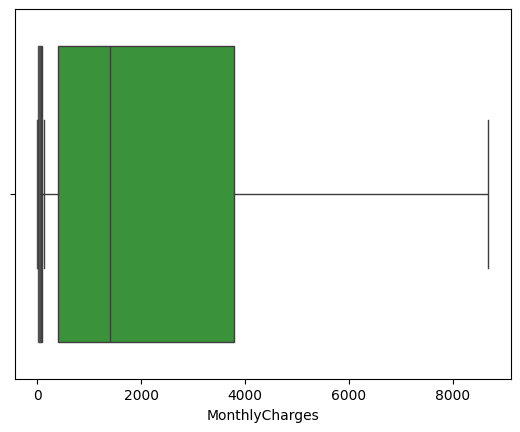

In [25]:
import seaborn as sns
sns.boxplot(x=df['MonthlyCharges'])
sns.boxplot(x=df["tenure"])
sns.boxplot(x=df['TotalCharges'])

create visualizations

<Axes: xlabel='Churn', ylabel='count'>

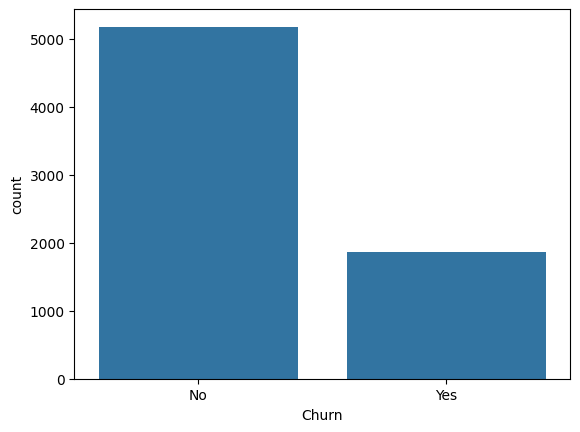

In [26]:
sns.countplot(x='Churn',data=df)

<Axes: xlabel='Contract', ylabel='count'>

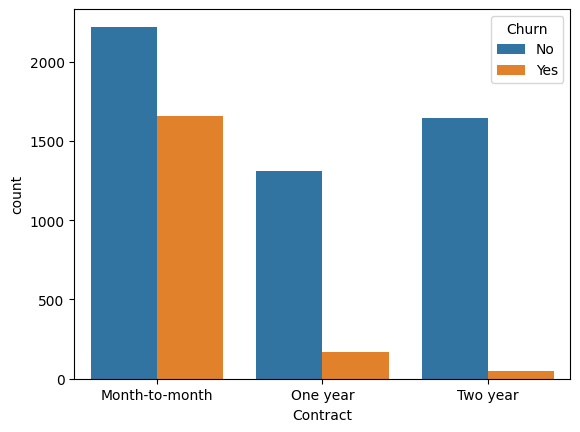

In [28]:
sns.countplot(x='Contract',hue="Churn",data=df)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

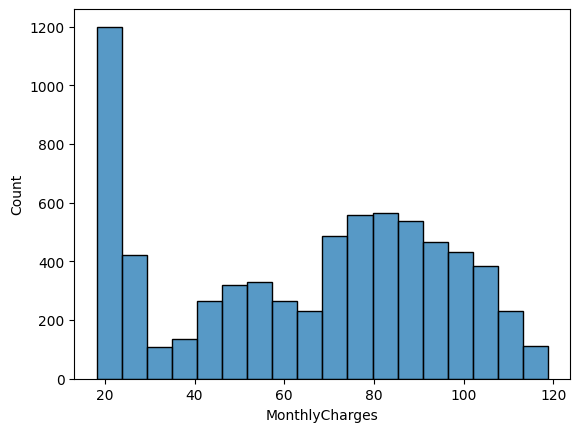

In [31]:
sns.histplot(df["MonthlyCharges"])

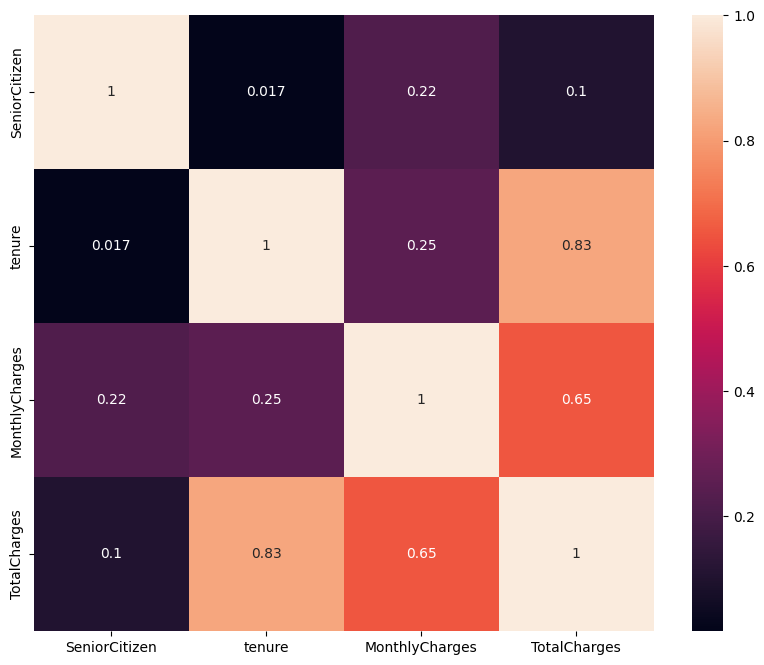

In [32]:
import matplotlib.pyplot as plt
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(),annot=True)
plt.show()

# Key Findings

- The dataset contains 7043 customer records and 21 features.
- Missing values were identified and handled.
- Duplicate records were checked and removed if present.
- Customers with month-to-month contracts show higher churn rates.
- Customers with longer tenure are less likely to churn.
- MonthlyCharges and TotalCharges are positively related.
- Correlation analysis revealed important feature relations

# Conclusion

This project focused on cleaning and visualizing the Telco Customer Churn dataset. Missing values, duplicates, and data quality issues were addressed. Multiple visualizations were created using Pandas, Matplotlib, and Seaborn to uncover customer behavior patterns. The analysis provides meaningful insights that can help businesses understand customer retention and churn trends.


# Executive Summary

## Key Findings
1. Customers on month-to-month contracts are more likely to churn.
2. Customers with shorter tenure exhibit higher churn rates.
3. Higher monthly charges are associated with increased churn probability.
4. Long-term customers tend to remain loyal and are less likely to leave.
5. Contract type, tenure, and monthly charges appear to be important churn indicators.

## Business Recommendations
- Promote annual and multi-year contracts through targeted discounts.
- Implement retention campaigns for high-risk customers.
- Introduce loyalty rewards for long-tenure customers.
- Provide personalized offers to customers with higher monthly charges.
- Continuously monitor churn-related metrics to support proactive decision-making.



# Final Conclusion

This project successfully performed data cleaning, preprocessing, and exploratory analysis on the Telco Customer Churn dataset. The analysis highlighted several customer characteristics that are strongly associated with churn behavior.

The findings can help telecom companies design targeted retention strategies, improve customer satisfaction, and reduce revenue loss caused by customer attrition. This project demonstrates practical data analytics skills including data preparation, visualization, insight generation, and business-oriented interpretation of results.

## Future Enhancements
- Build predictive machine learning models for churn prediction.
- Compare multiple classification algorithms.
- Perform feature importance analysis.
- Deploy the model using Streamlit or Flask.
- Create an interactive dashboard for business stakeholders.
